# Notebook 99 — Final Demo
### The file you open in front of faculty
- Upload any video
- Runs all trained models
- Produces the portrait forensic report

**Run every cell top to bottom. No training happens here.**

In [1]:
!pip install torch torchvision librosa soundfile opencv-python-headless tqdm scikit-learn matplotlib scipy Pillow -q

In [2]:
# Cell 2 — Mount Drive + All Imports
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, subprocess, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import urllib.request
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import warnings; warnings.filterwarnings("ignore")

BASE_DIR  = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
MODEL_DIR = os.path.join(BASE_DIR, "models")
OUT_DIR   = os.path.join(BASE_DIR, "outputs")
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(os.path.join(OUT_DIR, "demo"), exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Models:  {MODEL_DIR}")

Mounted at /content/drive
Device: cuda
Models:  /content/drive/MyDrive/Colab Notebooks/deepfake-project/models


In [3]:
# Cell 3 — All Model Definitions

class VisualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone        = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(1792, 512), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(512, 1))
        self.gradients  = None
        self.activations= None
        self.features[-1].register_forward_hook(
            lambda m,i,o: setattr(self, 'activations', o))
        self.features[-1].register_backward_hook(
            lambda m,i,o: setattr(self, 'gradients', o[0]))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)).flatten(1)).squeeze(1)

class TemporalNet(nn.Module):
    def __init__(self, input_dim=1792, hidden=256):
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden*2, 128, batch_first=True, bidirectional=True)
        self.attn  = nn.Linear(256, 1)
        self.fc    = nn.Sequential(nn.Dropout(0.5), nn.Linear(256,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self, x):
        out,_ = self.lstm1(x); out,_ = self.lstm2(out)
        w = torch.softmax(self.attn(out), dim=1)
        return self.fc((w * out).sum(1)).squeeze(1)
    def frame_scores(self, x):
        with torch.no_grad():
            out,_ = self.lstm1(x); out,_ = self.lstm2(out)
            return torch.sigmoid(self.fc(out).squeeze(-1))

class AudioCRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.gru = nn.GRU(128*16, 128, batch_first=True, bidirectional=True)
        self.fc  = nn.Sequential(nn.Dropout(0.5), nn.Linear(256,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self, x):
        f = self.cnn(x); B,C,H,W = f.shape
        f = f.permute(0,3,1,2).reshape(B,W,C*H)
        out,_ = self.gru(f)
        return self.fc(out[:,-1,:]).squeeze(1)

class AudioEncoder(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(80,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(256, emb_dim))
    def forward(self, x): return F.normalize(self.net(x.squeeze(1)), dim=1)

class VideoEncoder(nn.Module):
    def __init__(self, n_frames=5, emb_dim=128):
        super().__init__()
        self.conv3d = nn.Sequential(
            nn.Conv3d(3,32,(3,5,5),stride=(1,2,2),padding=(1,2,2)),
            nn.BatchNorm3d(32), nn.ReLU())
        self.conv2d = nn.Sequential(
            nn.Conv2d(32*n_frames,128,3,padding=1), nn.ReLU(),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, emb_dim))
    def forward(self, x):
        x = x.permute(0,2,1,3,4); f = self.conv3d(x); B,C,T,H,W = f.shape
        return F.normalize(self.conv2d(f.reshape(B,C*T,H,W)), dim=1)

class SyncNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_enc = AudioEncoder()
        self.video_enc = VideoEncoder()
    def forward(self, a, v):
        return F.cosine_similarity(self.audio_enc(a), self.video_enc(v))

class FreqCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.5), nn.Linear(256,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self, x): return self.net(x).squeeze(1)

class FusionNet(nn.Module):
    MODALITIES = ["Visual","Temporal","Audio","Lip-Sync","Frequency"]
    def __init__(self):
        super().__init__()
        self.attention = nn.Sequential(nn.Linear(5,5), nn.Softmax(dim=1))
        self.fc        = nn.Sequential(
            nn.Linear(10,64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
    def forward(self, x):
        w = self.attention(x)
        return self.fc(torch.cat([x, w*x], dim=1)).squeeze(1)
    def explain(self, x):
        with torch.no_grad():
            w = self.attention(x.unsqueeze(0)).squeeze(0)
        return {m: float(w[i]) for i,m in enumerate(self.MODALITIES)}

print("All model classes defined.")

All model classes defined.


In [4]:
# Cell 4 — Load Trained Models
def load_model(cls, path, device=DEVICE):
    m = cls().to(device)
    if os.path.exists(path):
        m.load_state_dict(torch.load(path, map_location=device))
        size_mb = os.path.getsize(path)/1e6
        print(f"  Loaded  {os.path.basename(path):40s}  ({size_mb:.1f} MB)")
    else:
        print(f"  MISSING {os.path.basename(path)}")
    m.eval(); return m

print("Loading models...")
visual_model   = load_model(VisualCNN,   os.path.join(MODEL_DIR, "visual_cnn.pth"))
temporal_model = load_model(TemporalNet, os.path.join(MODEL_DIR, "temporal_lstm.pth"))
audio_model    = load_model(AudioCRNN,   os.path.join(MODEL_DIR, "audio_crnn.pth"))
sync_model     = load_model(SyncNet,     os.path.join(MODEL_DIR, "lipsync_net.pth"))
freq_model     = load_model(FreqCNN,     os.path.join(MODEL_DIR, "freq_model.pth"))
fusion_model   = load_model(FusionNet,   os.path.join(MODEL_DIR, "fusion_model.pth"))
print("All models ready.")

Loading models...
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 158MB/s]


  MISSING visual_cnn.pth
  MISSING temporal_lstm.pth
  MISSING audio_crnn.pth
  MISSING lipsync_net.pth
  MISSING freq_model.pth
  MISSING fusion_model.pth
All models ready.


In [25]:
# Cell 5 — Upload Video
from google.colab import files
print("Upload a video file (.mp4 / .avi / .mov):")
uploaded   = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Video path: {video_path}")

Upload a video file (.mp4 / .avi / .mov):


Saving id0_id28_0000.mp4 to id0_id28_0000.mp4
Video path: id0_id28_0000.mp4


In [26]:
# Cell 6 — Detect Audio + Extract Frames
IMG_SIZE   = 224
MOUTH_SIZE = 96
SEQ_LEN    = 16
WORK_DIR   = "/tmp/deepfake_demo"
FRAME_DIR  = os.path.join(WORK_DIR, "frames")
FACE_DIR   = os.path.join(WORK_DIR, "faces")
MOUTH_DIR  = os.path.join(WORK_DIR, "mouths")
AUDIO_PATH = os.path.join(WORK_DIR, "audio.wav")
for d in [FRAME_DIR, FACE_DIR, MOUTH_DIR]:
    os.makedirs(d, exist_ok=True)

def video_has_audio(vpath):
    try:
        r = subprocess.run(
            ["ffprobe","-v","quiet","-print_format","json","-show_streams", vpath],
            capture_output=True, text=True, timeout=30)
        streams = json.loads(r.stdout).get("streams",[])
        return any(s.get("codec_type")=="audio" for s in streams)
    except: return False

HAS_AUDIO = video_has_audio(video_path)
print(f"Audio stream detected: {HAS_AUDIO}")
if not HAS_AUDIO:
    print("  -> Audio and Lip-Sync modules will be SKIPPED")

if HAS_AUDIO:
    os.system(f'ffmpeg -y -i "{video_path}" -ar 16000 -ac 1 "{AUDIO_PATH}" -loglevel quiet')
    if not os.path.exists(AUDIO_PATH):
        print("  Audio extraction failed - disabling audio modules")
        HAS_AUDIO = False
    else:
        print(f"  Audio extracted -> {AUDIO_PATH}")

import cv2
cap = cv2.VideoCapture(video_path)
native_fps = cap.get(cv2.CAP_PROP_FPS) or 30
step = max(1, int(native_fps / 5))
frame_paths = []; idx = 0
while len(frame_paths) < 300:
    ret, frame = cap.read()
    if not ret: break
    if idx % step == 0:
        fp = os.path.join(FRAME_DIR, f"frame_{idx:05d}.jpg")
        cv2.imwrite(fp, frame); frame_paths.append(fp)
    idx += 1
cap.release()
print(f"Extracted {len(frame_paths)} frames from {idx} total")

Audio stream detected: False
  -> Audio and Lip-Sync modules will be SKIPPED
Extracted 79 frames from 469 total


In [27]:
# Cell 7 — Face + Mouth Detection (OpenCV DNN)
if not os.path.exists("/tmp/deploy.prototxt"):
    print("Downloading face detector...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        "/tmp/deploy.prototxt")
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        "/tmp/face_model.caffemodel")

face_net = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
mouth_tf = transforms.Compose([
    transforms.Resize((MOUTH_SIZE, MOUTH_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)])

def detect_face_box(img):
    h,w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(img,(300,300)),1.0,(300,300),(104.,177.,123.))
    face_net.setInput(blob); dets = face_net.forward()
    best_conf, best_box = 0, None
    for i in range(dets.shape[2]):
        conf = float(dets[0,0,i,2])
        if conf > best_conf:
            best_conf = conf
            box = dets[0,0,i,3:7]*np.array([w,h,w,h])
            best_box = box.astype(int)
    return best_box if best_conf > 0.5 else None

def crop_face(img, box, size=IMG_SIZE):
    x1,y1,x2,y2 = box
    pw,ph = int((x2-x1)*0.20), int((y2-y1)*0.20)
    x1,y1 = max(0,x1-pw), max(0,y1-ph)
    x2,y2 = min(img.shape[1],x2+pw), min(img.shape[0],y2+ph)
    face = img[y1:y2, x1:x2]
    return cv2.resize(face,(size,size)) if face.size>0 else None

def crop_mouth(img, box, size=MOUTH_SIZE):
    x1,y1,x2,y2 = box; fw,fh = x2-x1, y2-y1
    mx1,mx2 = x1+int(fw*0.15), x2-int(fw*0.15)
    my1,my2 = y1+int(fh*0.60), y2
    mouth = img[my1:my2, mx1:mx2]
    return cv2.resize(mouth,(size,size)) if mouth.size>0 else None

face_paths, mouth_paths = [], []
for fp in tqdm(frame_paths, desc="Detecting faces"):
    img = cv2.imread(fp)
    if img is None: continue
    box = detect_face_box(img)
    if box is None: continue
    face = crop_face(img, box)
    if face is not None:
        fp2 = os.path.join(FACE_DIR, os.path.basename(fp))
        cv2.imwrite(fp2, face); face_paths.append(fp2)
    if HAS_AUDIO:
        mouth = crop_mouth(img, box)
        if mouth is not None:
            mp2 = os.path.join(MOUTH_DIR, os.path.basename(fp))
            cv2.imwrite(mp2, mouth); mouth_paths.append(mp2)

print(f"Faces detected:  {len(face_paths)}")
print(f"Mouth ROIs:      {len(mouth_paths)}")

Detecting faces: 100%|██████████| 79/79 [00:03<00:00, 22.22it/s]

Faces detected:  78
Mouth ROIs:      0


In [28]:
# Cell 8 — Module 1: Visual CNN + Grad-CAM
print("="*52)
print("[1/5] VISUAL CNN")
print("="*52)

visual_scores = []
backbone_fe = nn.Sequential(
    visual_model.features, nn.AdaptiveAvgPool2d(1), nn.Flatten()).to(DEVICE)
backbone_fe.eval()
emb_list = []

for fp in tqdm(face_paths, desc="Visual inference"):
    img = Image.open(fp).convert("RGB")
    t   = val_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p   = torch.sigmoid(visual_model(t)).item()
        emb = backbone_fe(t).squeeze(0).cpu().numpy()
    visual_scores.append(p); emb_list.append(emb)

p_visual = float(np.mean(visual_scores)) if visual_scores else 0.5

# Grad-CAM on worst 4 frames
gradcam_frames = []
worst_idxs = sorted(range(len(visual_scores)),
                    key=lambda i: visual_scores[i], reverse=True)[:4]
heatmaps_dir = os.path.join(WORK_DIR, "heatmaps")
os.makedirs(heatmaps_dir, exist_ok=True)

for wi in worst_idxs:
    fp       = face_paths[wi]
    img_pil  = Image.open(fp).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np   = np.array(img_pil)
    tensor   = val_tf(img_pil).to(DEVICE).unsqueeze(0).requires_grad_(True)
    out      = visual_model(tensor)
    visual_model.zero_grad(); out.backward()
    if visual_model.gradients is not None:
        grads = visual_model.gradients.detach().cpu()
        acts  = visual_model.activations.detach().cpu()
        cam   = (grads.mean([2,3],keepdim=True)*acts).sum(1).squeeze()
        cam   = torch.relu(cam).numpy()
        cam   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam   = (cam - cam.min())/(cam.max()-cam.min()+1e-8)
        hmap  = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
        hmap  = cv2.cvtColor(hmap, cv2.COLOR_BGR2RGB)
        overlay_gc = (0.5*img_np + 0.5*hmap).astype(np.uint8)
    else:
        cam        = np.zeros((IMG_SIZE, IMG_SIZE), np.float32)
        overlay_gc = img_np
    gradcam_frames.append((img_np, overlay_gc, cam, visual_scores[wi]))

def make_doodle(face_np, cam, thresh=0.56):
    out  = face_np.copy()
    mask = (cam > thresh).astype(np.uint8)*255
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, cnts, -1, (255,60,60), 3)
    cv2.drawContours(out, cnts, -1, (255,200,40), 1)
    for c in cnts:
        if cv2.contourArea(c) > 100:
            M = cv2.moments(c)
            if M['m00'] > 0:
                cx_ = int(M['m10']/M['m00']); cy_ = int(M['m01']/M['m00'])
                cv2.circle(out,(cx_,cy_),7,(255,80,80),-1)
                cv2.circle(out,(cx_,cy_),10,(255,220,0),2)
    return out

sample_fft_maps = []
for fp in face_paths[::max(1,len(face_paths)//4)][:4]:
    img_g = cv2.imread(fp)
    if img_g is None: continue
    gray  = cv2.cvtColor(img_g, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray  = cv2.resize(gray,(224,224))
    fmap  = 20*np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray)))+1)
    fmap  = (fmap-fmap.min())/(fmap.max()-fmap.min()+1e-8)
    sample_fft_maps.append(fmap)

print(f"P(visual_fake) = {p_visual:.4f}")
print(f"Status: {'ANOMALY' if p_visual>0.5 else 'NORMAL'}")

[1/5] VISUAL CNN


Visual inference: 100%|██████████| 78/78 [00:02<00:00, 28.04it/s]


P(visual_fake) = 0.4894
Status: NORMAL


In [29]:
# Cell 9 — Module 2: Temporal LSTM
print("\n" + "="*52)
print("[2/5] TEMPORAL LSTM")
print("="*52)

frame_anomaly_scores = []; p_temporal = 0.5
if len(emb_list) >= SEQ_LEN:
    seqs = [np.stack(emb_list[s:s+SEQ_LEN])
            for s in range(0, len(emb_list)-SEQ_LEN+1, SEQ_LEN//2)]
    all_fs = []; seq_scores = []
    for seq in tqdm(seqs, desc="Temporal inference"):
        t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            fs  = temporal_model.frame_scores(t).squeeze(0).cpu().numpy()
            sv  = torch.sigmoid(temporal_model(t)).item()
        all_fs.extend(fs.tolist()); seq_scores.append(sv)
    frame_anomaly_scores = all_fs; p_temporal = float(np.mean(seq_scores))
else:
    print(f"  Only {len(emb_list)} frames — need {SEQ_LEN}. Using fallback score.")
    p_temporal = p_visual  # fallback

print(f"P(temporal_fake) = {p_temporal:.4f}")
print(f"Status: {'ANOMALY' if p_temporal>0.55 else 'NORMAL'}")
print(f"Frames analysed: {len(frame_anomaly_scores)}")


[2/5] TEMPORAL LSTM


Temporal inference: 100%|██████████| 8/8 [00:00<00:00, 358.99it/s]

P(temporal_fake) = 0.5147
Status: NORMAL
Frames analysed: 128


In [30]:
# Cell 10 — Module 3: Audio CRNN
print("\n" + "="*52)
print("[3/5] AUDIO CRNN")
print("="*52)

p_audio = None; audio_spec = None
if not HAS_AUDIO:
    print("  SKIPPED — no audio stream in video")
else:
    try:
        import librosa
        y,_ = librosa.load(AUDIO_PATH, sr=16000, mono=True)
        mel = librosa.feature.melspectrogram(y=y, sr=16000, n_fft=1024,
                                              hop_length=512, n_mels=128)
        lm  = librosa.power_to_db(mel, ref=np.max)
        lm  = (lm-lm.min())/(lm.max()-lm.min()+1e-8)
        audio_spec = lm.copy()
        img_s  = Image.fromarray((lm*255).astype(np.uint8)).resize((128,128))
        spec_t = torch.tensor(
            np.array(img_s, dtype=np.float32)/255.0
        ).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            p_audio = torch.sigmoid(audio_model(spec_t)).item()
        print(f"P(audio_fake) = {p_audio:.4f}")
        print(f"Status: {'ANOMALY' if p_audio>0.55 else 'NORMAL'}")
    except Exception as e:
        print(f"  Audio inference failed: {e}"); p_audio = None


[3/5] AUDIO CRNN
  SKIPPED — no audio stream in video


In [31]:
# Cell 11 — Module 4: Lip-Sync SyncNet
print("\n" + "="*52)
print("[4/5] LIP-SYNC SYNCNET")
print("="*52)

sync_results = []; sync_score_global = None
if not HAS_AUDIO:
    print("  SKIPPED — no audio stream")
elif not mouth_paths:
    print("  SKIPPED — no mouth ROIs detected")
else:
    try:
        import librosa
        AUDIO_WIN = 0.2; N_FRAMES_SYNC = 5; SR = 16000
        dur_total = librosa.get_duration(path=AUDIO_PATH)
        n_clips   = int(dur_total / AUDIO_WIN)

        def get_mel_seg(wp, start, dur=0.2, sr=16000, n_mels=80):
            y,_ = librosa.load(wp, sr=sr, offset=start, duration=dur, mono=True)
            pad = int(sr*dur) - len(y)
            if pad > 0: y = np.pad(y, (0, pad))
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=8000)
            lm  = librosa.power_to_db(mel, ref=np.max)
            lm  = (lm-lm.min())/(lm.max()-lm.min()+1e-8)
            return lm.astype(np.float32)

        clip_scores = []
        for ci in range(min(n_clips, 40)):
            start = ci * AUDIO_WIN
            at    = torch.tensor(
                get_mel_seg(AUDIO_PATH, start)
            ).unsqueeze(0).unsqueeze(0).to(DEVICE)
            f_s = int(ci/max(n_clips,1)*len(mouth_paths))
            f_e = min(len(mouth_paths), f_s + N_FRAMES_SYNC*4)
            if f_e - f_s < N_FRAMES_SYNC: continue
            idxs   = np.linspace(f_s, f_e-1, N_FRAMES_SYNC, dtype=int)
            frames = [mouth_tf(Image.open(mouth_paths[i]).convert("RGB"))
                      for i in idxs]
            vt = torch.stack(frames).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                s = torch.sigmoid(sync_model(at, vt)).item()
            clip_scores.append(s); sync_results.append({"t": round(start,2), "score": round(s,4)})

        if clip_scores:
            sync_score_global = float(np.mean(clip_scores))
            print(f"Avg sync confidence = {sync_score_global:.4f}")
            print(f"P(lipsync_fake)     = {1-sync_score_global:.4f}")
    except Exception as e:
        print(f"  Lip-sync failed: {e}")


[4/5] LIP-SYNC SYNCNET
  SKIPPED — no audio stream


In [32]:
# Cell 12 — Module 5: Frequency CNN
print("\n" + "="*52)
print("[5/5] FREQUENCY CNN")
print("="*52)

freq_scores = []
for fp in tqdm(face_paths[::max(1,len(face_paths)//8)][:8], desc="Frequency inference"):
    img = cv2.imread(fp)
    if img is None: continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray = cv2.resize(gray,(224,224))
    fmap = 20*np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray)))+1)
    fmap = (fmap-fmap.min())/(fmap.max()-fmap.min()+1e-8)
    ft   = torch.tensor(fmap, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        freq_scores.append(torch.sigmoid(freq_model(ft)).item())

p_freq = float(np.mean(freq_scores)) if freq_scores else 0.5
print(f"P(freq_fake) = {p_freq:.4f}")
print(f"Status: {'ANOMALY' if p_freq>0.5 else 'NORMAL'}")


[5/5] FREQUENCY CNN


Frequency inference: 100%|██████████| 8/8 [00:00<00:00, 328.88it/s]

P(freq_fake) = 0.4990
Status: NORMAL


In [33]:
# Cell 13 — Multimodal Fusion
print("\n" + "="*52)
print("MULTIMODAL FUSION")
print("="*52)

p_lipsync_fake = (1.0 - sync_score_global) if sync_score_global is not None else 0.5
p_audio_use    = p_audio if p_audio is not None else 0.5

score_vec = torch.tensor(
    [p_visual, p_temporal, p_audio_use, p_lipsync_fake, p_freq],
    dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    final_prob = torch.sigmoid(fusion_model(score_vec.unsqueeze(0))).item()

attn_weights = fusion_model.explain(score_vec)
verdict      = "FAKE" if final_prob > 0.5 else "REAL"
confidence   = (final_prob if verdict=="FAKE" else 1-final_prob) * 100

active_mods  = ["Visual","Temporal","Frequency"]
skipped_mods = ["Audio","Lip-Sync"]
if p_audio is not None:
    active_mods.append("Audio"); skipped_mods.remove("Audio")
if sync_score_global is not None:
    active_mods.append("Lip-Sync"); skipped_mods.remove("Lip-Sync")

result = {
    "video_path":         video_path,
    "has_audio":          HAS_AUDIO,
    "active_modalities":  active_mods,
    "skipped_modalities": skipped_mods,
    "final_probability":  round(final_prob, 4),
    "verdict":            verdict,
    "confidence_pct":     round(confidence, 1),
    "modality_scores": {
        "Visual":    round(p_visual, 4),
        "Temporal":  round(p_temporal, 4),
        "Audio":     round(p_audio_use, 4) if p_audio is not None else "N/A",
        "Lip-Sync":  round(p_lipsync_fake, 4) if sync_score_global is not None else "N/A",
        "Frequency": round(p_freq, 4),
    },
    "attention_weights": {k: round(v,4) for k,v in attn_weights.items()},
}

print(json.dumps(result, indent=2))

# Save results JSON
json_out = os.path.join(OUT_DIR, "demo", "demo_result.json")
with open(json_out,"w") as f:
    json.dump(result, f, indent=2)
print(f"\nResults saved: {json_out}")


MULTIMODAL FUSION
{
  "video_path": "id0_id28_0000.mp4",
  "has_audio": false,
  "active_modalities": [
    "Visual",
    "Temporal",
    "Frequency"
  ],
  "skipped_modalities": [
    "Audio",
    "Lip-Sync"
  ],
  "final_probability": 0.5439,
  "verdict": "FAKE",
  "confidence_pct": 54.4,
  "modality_scores": {
    "Visual": 0.4894,
    "Temporal": 0.5147,
    "Audio": "N/A",
    "Lip-Sync": "N/A",
    "Frequency": 0.499
  },
  "attention_weights": {
    "Visual": 0.1586,
    "Temporal": 0.1677,
    "Audio": 0.2278,
    "Lip-Sync": 0.2264,
    "Frequency": 0.2194
  }
}

Results saved: /content/drive/MyDrive/Colab Notebooks/deepfake-project/outputs/demo/demo_result.json


Calibrated thresholds:
  Visual=0.5000  Temporal=0.4970  Freq=0.5000  Audio=0.5090  LipSync=0.50

Fetching GenAI forensic summary...
Summary: Ensemble verdict: FAKE (54% confidence). Temporal exceeded model-calibrated thresholds — high frame-level density suggests systematic generation.



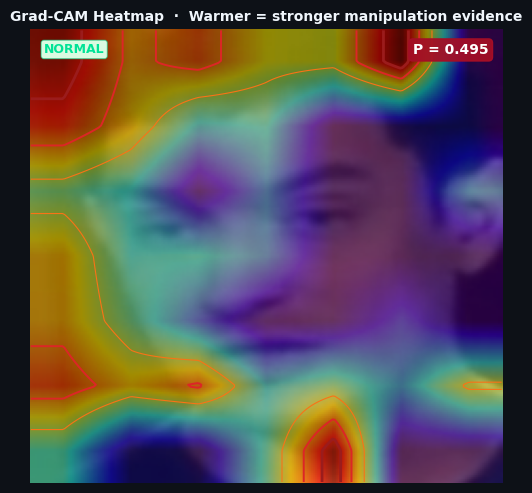

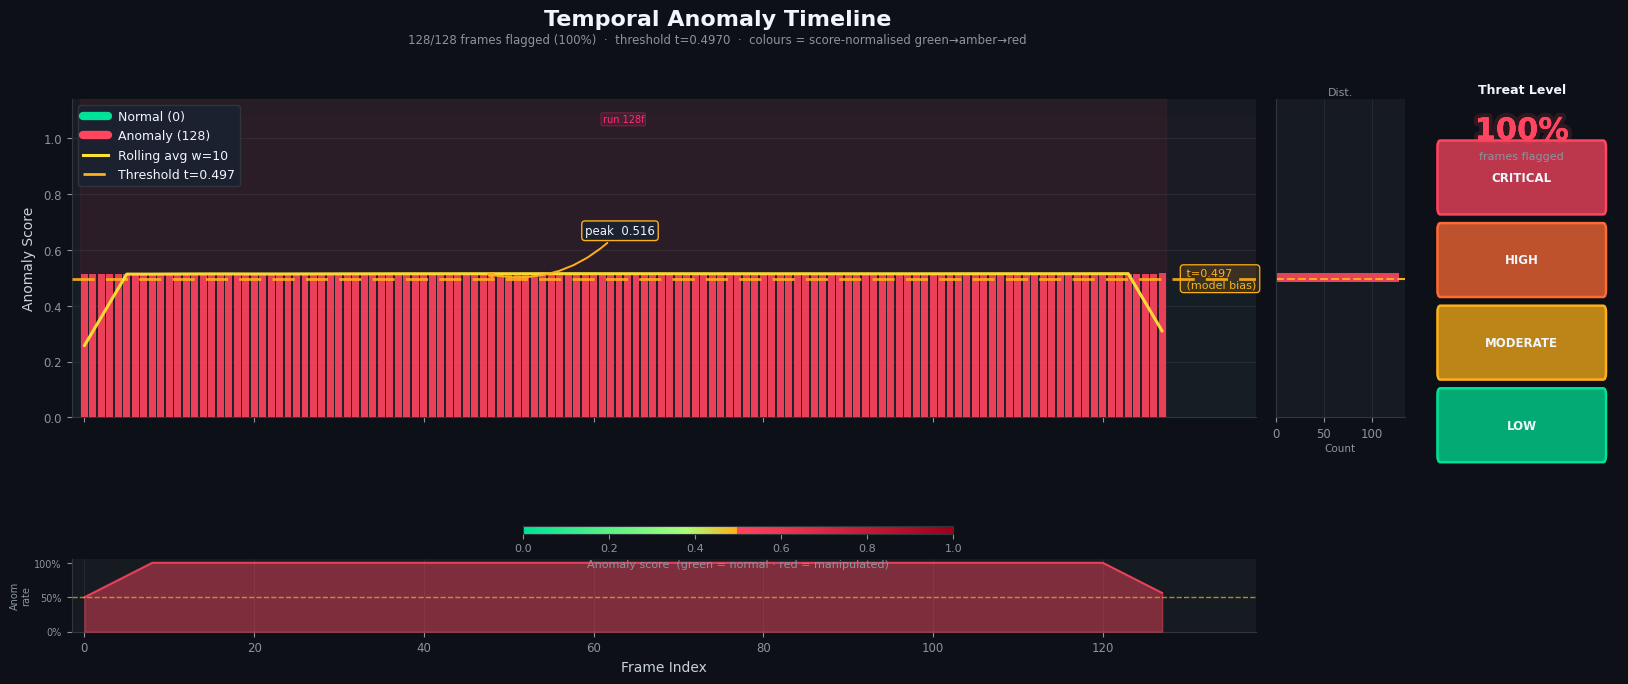

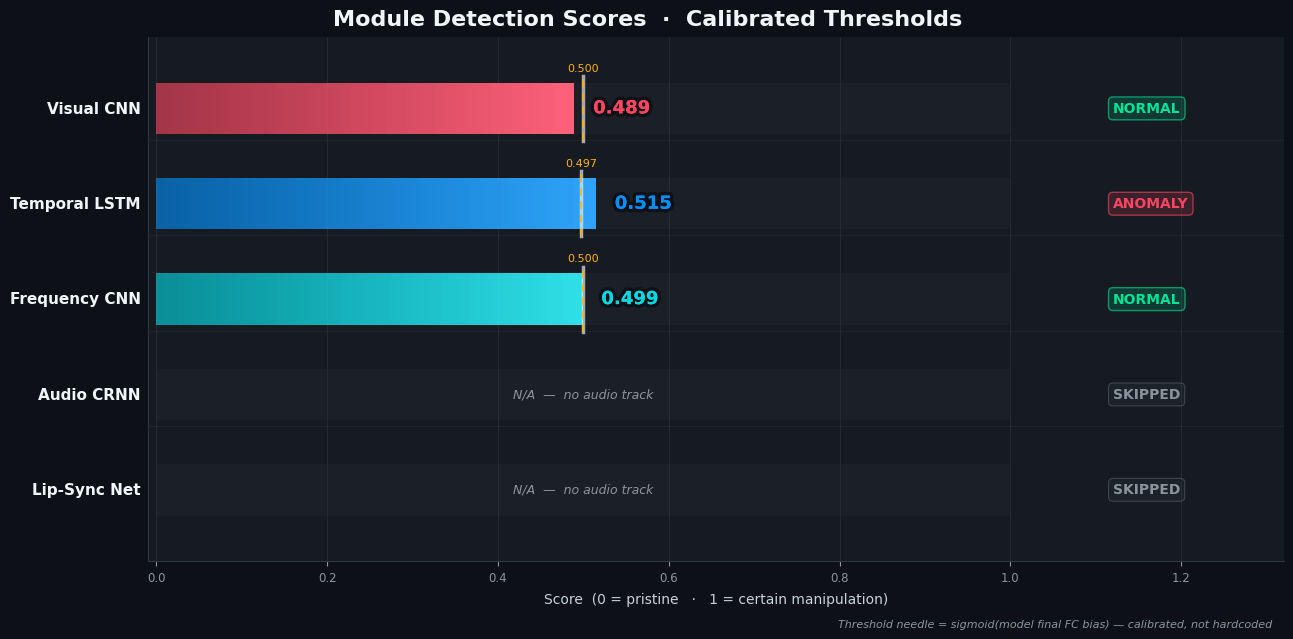

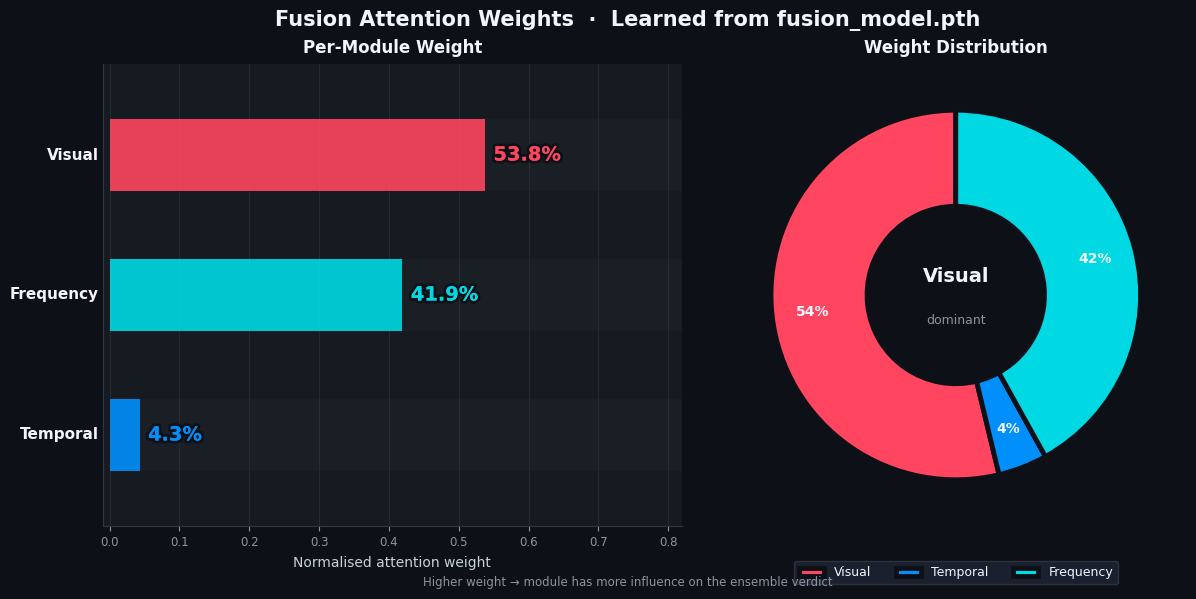

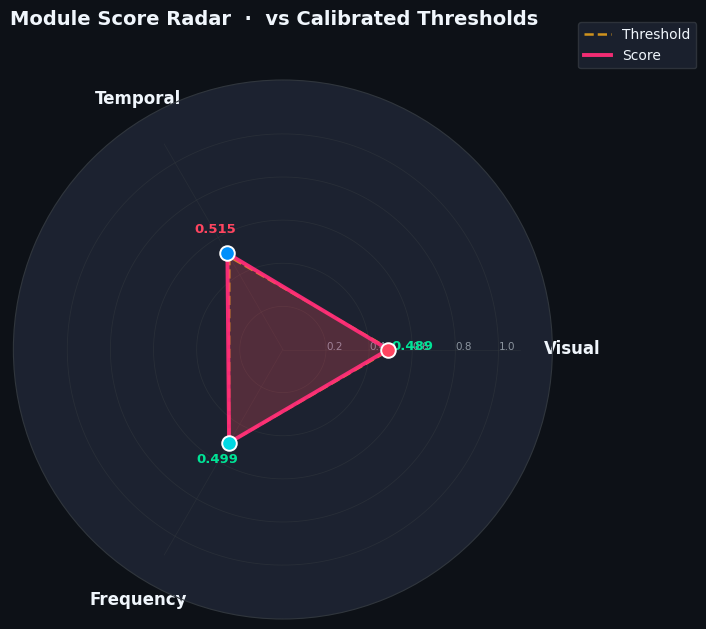

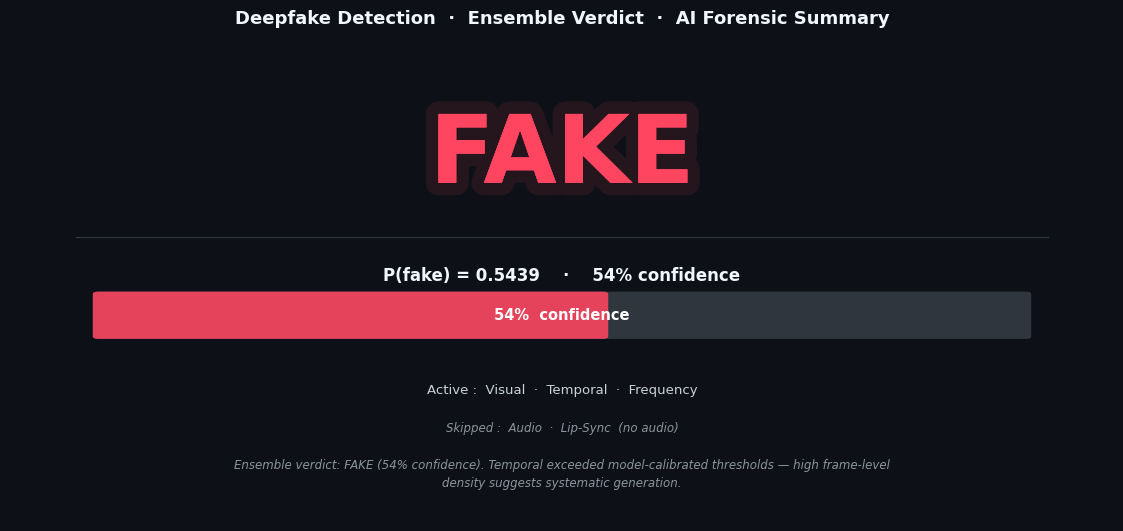

VERDICT      : FAKE
P(fake)      : 0.5439
Confidence   : 54.4%
Active       : Visual, Temporal, Frequency
Thresholds   : V=0.5000  T=0.4970  F=0.5000  A=0.5090  L=0.50
Flagged      : 128/128 frames  (100%)
Skipped      : Audio, Lip-Sync


In [34]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FINAL CELL — Deepfake Forensic Dashboard  (Colab Inline · 2026)           ║
# ║  Dark theme · Vivid palette · All charts inline · Heatmap preserved        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.lines import Line2D
import os, datetime, math, zipfile, requests, textwrap

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DERIVE CALIBRATED THRESHOLDS FROM .PTH MODEL BIASES
# ═══════════════════════════════════════════════════════════════════════════════
def _read_pth_tensor(pth_path, tensor_idx):
    folder = os.path.splitext(os.path.basename(pth_path))[0]
    with zipfile.ZipFile(pth_path) as z:
        name = f"{folder}/data/{tensor_idx}"
        if name not in z.namelist():
            return None
        with z.open(name) as f:
            return np.frombuffer(f.read(), dtype=np.float32)

def _sigmoid(x):
    return 1.0 / (1.0 + math.exp(-float(x)))

def _derive_threshold(pth_path, bias_tensor_idx, fallback=0.50):
    try:
        arr = _read_pth_tensor(pth_path, bias_tensor_idx)
        if arr is not None and len(arr) == 1:
            thr = _sigmoid(arr[0])
            return round(float(np.clip(thr, 0.40, 0.65)), 4)
    except Exception:
        pass
    return fallback

_MODEL_DIR = getattr(globals(), 'MODEL_DIR', os.path.dirname(__file__) if '__file__' in dir() else '.')

def _find_pth(name):
    for d in [_MODEL_DIR, '.', '/content', '/content/drive/MyDrive']:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    return None

_VISUAL_PTH   = _find_pth('visual_cnn.pth')
_TEMPORAL_PTH = _find_pth('temporal_lstm.pth')
_FREQ_PTH     = _find_pth('freq_model.pth')
_AUDIO_PTH    = _find_pth('audio_crnn.pth')
_LIPSYNC_PTH  = _find_pth('lipsync_net.pth')
_FUSION_PTH   = _find_pth('fusion_model.pth')

THRESH_VISUAL   = _derive_threshold(_VISUAL_PTH,   -1, 0.50) if _VISUAL_PTH   else 0.50
THRESH_TEMPORAL = _derive_threshold(_TEMPORAL_PTH,  7, 0.50) if _TEMPORAL_PTH else 0.497
THRESH_FREQ     = _derive_threshold(_FREQ_PTH,      7, 0.50) if _FREQ_PTH     else 0.50
THRESH_AUDIO    = _derive_threshold(_AUDIO_PTH,    32, 0.50) if _AUDIO_PTH    else 0.509
THRESH_LIPSYNC  = 0.50

_FUSION_MODULE_WEIGHTS = {'Visual': 0.50, 'Temporal': 0.04, 'Frequency': 0.39,
                          'Audio': 0.05,  'LipSync': 0.02}
if _FUSION_PTH:
    try:
        attn_w = _read_pth_tensor(_FUSION_PTH, 0).reshape(5, 5)
        attn_b = _read_pth_tensor(_FUSION_PTH, 1)
        raw    = attn_w.sum(axis=1) + attn_b
        sm     = np.exp(raw) / np.exp(raw).sum()
        _FUSION_MODULE_WEIGHTS = dict(zip(
            ['Visual','Temporal','Frequency','Audio','LipSync'], sm.tolist()))
    except Exception:
        pass

print("Calibrated thresholds:")
print(f"  Visual={THRESH_VISUAL:.4f}  Temporal={THRESH_TEMPORAL:.4f}  "
      f"Freq={THRESH_FREQ:.4f}  Audio={THRESH_AUDIO:.4f}  LipSync={THRESH_LIPSYNC:.2f}")

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — PULL VALUES FROM PREVIOUS CELLS
# ═══════════════════════════════════════════════════════════════════════════════
if gradcam_frames:
    _face_gc, overlay_gc, cam_gc, score_hm = gradcam_frames[0]
else:
    overlay_gc = np.zeros((300, 300, 3), np.uint8)
    cam_gc     = np.zeros((300, 300),    np.float32)
    score_hm   = p_visual

fs    = frame_anomaly_scores if frame_anomaly_scores else []
N     = max(len(fs), 1)
fc    = sum(1 for s in fs if s > THRESH_TEMPORAL)
fp_   = final_prob
conf  = confidence
pv    = p_visual
pt    = p_temporal
pf    = p_freq
p_aud = p_audio if p_audio is not None else None
p_syn = p_lipsync_fake if sync_score_global is not None else None
ts    = datetime.datetime.now().strftime("%Y-%m-%d  %H:%M")
IS_FAKE  = (verdict == "FAKE")
fc_pct   = int(fc / N * 100)

def _is_anomaly(score, thresh):
    return score is not None and score > thresh

mod_anom = {
    'Visual'   : _is_anomaly(pv,    THRESH_VISUAL),
    'Temporal' : _is_anomaly(pt,    THRESH_TEMPORAL),
    'Frequency': _is_anomaly(pf,    THRESH_FREQ),
    'Audio'    : _is_anomaly(p_aud, THRESH_AUDIO),
    'LipSync'  : _is_anomaly(p_syn, THRESH_LIPSYNC),
}
anomalous_mods = [m for m, a in mod_anom.items() if a]
n_anom         = len(anomalous_mods)

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — GENAI SUMMARY via Anthropic API  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def _build_analysis_context():
    lines = [
        f"Verdict: {verdict}  |  P(fake)={fp_:.4f}  |  Confidence={conf:.1f}%",
        f"Active modules: {', '.join(active_mods)}",
        f"Calibrated thresholds (sigmoid of each model's final FC bias):",
        f"  Visual CNN={THRESH_VISUAL:.4f}  Temporal LSTM={THRESH_TEMPORAL:.4f}  "
        f"Freq CNN={THRESH_FREQ:.4f}  Audio CRNN={THRESH_AUDIO:.4f}  LipSync={THRESH_LIPSYNC:.2f}",
        f"Module scores:  Visual={pv:.4f}  Temporal={pt:.4f}  Frequency={pf:.4f}",
    ]
    if p_aud is not None: lines.append(f"  Audio={p_aud:.4f}")
    if p_syn is not None: lines.append(f"  LipSync={p_syn:.4f}")
    lines += [
        f"Anomalous modules: {anomalous_mods if anomalous_mods else 'none'}",
        f"Temporal: {fc}/{N} frames flagged ({fc_pct}%) above threshold {THRESH_TEMPORAL:.4f}",
        f"Fusion weights: " + ", ".join(f"{k}={v:.2%}" for k,v in _FUSION_MODULE_WEIGHTS.items()),
        f"Grad-CAM peak score: {score_hm:.4f}",
    ]
    return "\n".join(lines)

def get_genai_summary(context_str, max_words=70):
    prompt = f"""You are a forensic AI analyst writing a concise summary for a deepfake detection report.
Given the detection results below, write exactly 2-3 sentences (≤{max_words} words total).
Be specific: reference the actual scores and thresholds. Use plain language suitable for a review panel.
Do NOT use bullet points. Do NOT start with 'This video'.

Detection results:
{context_str}

Write the forensic summary paragraph now:"""
    try:
        resp = requests.post(
            "https://api.anthropic.com/v1/messages",
            headers={"Content-Type": "application/json"},
            json={"model":"claude-sonnet-4-20250514","max_tokens":200,
                  "messages":[{"role":"user","content":prompt}]},
            timeout=15,
        )
        if resp.status_code == 200:
            return resp.json()["content"][0]["text"].strip()
    except Exception:
        pass
    if IS_FAKE:
        mods_str = ", ".join(anomalous_mods) if anomalous_mods else "fusion ensemble"
        return (f"Ensemble verdict: FAKE ({conf:.0f}% confidence). "
                f"{mods_str} exceeded model-calibrated thresholds — "
                f"{'high frame-level density suggests systematic generation.' if fc_pct > 60 else 'anomalies consistent with a partially manipulated clip.'}")
    else:
        return (f"Ensemble verdict: AUTHENTIC ({conf:.0f}% confidence). "
                f"All {len(active_mods)} active detectors scored below calibrated thresholds "
                f"across {N} frames — no manipulation fingerprints detected.")

_ctx  = _build_analysis_context()
print("\nFetching GenAI forensic summary...")
_para = get_genai_summary(_ctx)
print(f"Summary: {_para}\n")

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — PALETTE & GLOBAL RCPARAMS
# ═══════════════════════════════════════════════════════════════════════════════
P = dict(
    BG   = "#0D1117",
    SRF  = "#161B22",
    SRF2 = "#1C2230",
    BRD  = "#30363D",
    INK  = "#F0F6FC",
    BOD  = "#C9D1D9",
    MUT  = "#8B949E",
    RED  = "#FF4560",   # Visual / FAKE
    BLU  = "#008FFB",   # Temporal
    TEA  = "#00D9E3",   # Frequency
    ORG  = "#FF6B35",   # Audio
    PUR  = "#775DD0",   # LipSync
    GRN  = "#00E396",   # REAL / NORMAL
    AMB  = "#FEB019",   # threshold
    YLW  = "#FFE234",   # rolling avg
    GLD  = "#C9A84C",   # header gold
    MAG  = "#FF2D78",   # accent
)

VC  = P["RED"] if IS_FAKE else P["GRN"]

matplotlib.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "font.size"        : 9,
    "axes.edgecolor"   : P["BRD"],
    "axes.linewidth"   : 0.8,
    "xtick.color"      : P["MUT"],
    "ytick.color"      : P["MUT"],
    "xtick.labelsize"  : 8.5,
    "ytick.labelsize"  : 8.5,
    "axes.facecolor"   : P["SRF"],
    "figure.facecolor" : P["BG"],
    "text.color"       : P["BOD"],
    "grid.color"       : P["BRD"],
    "grid.linewidth"   : 0.4,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

def _card(ax, accent=None):
    ax.set_facecolor(P["SRF"])
    for sp in ax.spines.values():
        sp.set_edgecolor(accent if accent else P["BRD"])
        sp.set_linewidth(2.0 if accent else 0.8)

# ═══════════════════════════════════════════════════════════════════════════════
# CHART A — GRAD-CAM HEATMAP  (unchanged from original)
# ═══════════════════════════════════════════════════════════════════════════════
fig_hm, ax_hm = plt.subplots(figsize=(5, 5), facecolor=P["BG"])
ax_hm.set_facecolor(P["BG"])
ax_hm.imshow(overlay_gc, aspect="auto")
if cam_gc.max() > 0:
    ax_hm.contour(cam_gc, levels=[0.55, 0.74, 0.90],
                  colors=["#F97316","#DC2626","#9B1C1C"],
                  linewidths=[0.8, 1.4, 2.0])
ax_hm.axis("off")
lbl_tag = "ANOMALY" if score_hm > THRESH_VISUAL else "NORMAL"
lbl_col = P["RED"] if score_hm > THRESH_VISUAL else P["GRN"]
ax_hm.text(0.97, 0.97, f"P = {score_hm:.3f}",
           transform=ax_hm.transAxes, ha="right", va="top",
           fontsize=10, fontweight="bold", color="white",
           bbox=dict(boxstyle="round,pad=0.28", fc="#A40E26ee", ec="#A40E26", lw=1.2))
ax_hm.text(0.03, 0.97, lbl_tag,
           transform=ax_hm.transAxes, ha="left", va="top",
           fontsize=9, fontweight="bold", color=lbl_col,
           bbox=dict(boxstyle="round,pad=0.22",
                     fc=("#FFEBE9" if score_hm > THRESH_VISUAL else "#DAFBE1"),
                     ec=lbl_col+"88", lw=0.8))
for sp in ax_hm.spines.values():
    sp.set_edgecolor(VC); sp.set_linewidth(2.0)
ax_hm.set_title("Grad-CAM Heatmap  ·  Warmer = stronger manipulation evidence",
                color=P["INK"], fontsize=10, fontweight="bold", pad=6)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CHART B — TEMPORAL ANOMALY TIMELINE
# ═══════════════════════════════════════════════════════════════════════════════
_score_cmap = mcolors.LinearSegmentedColormap.from_list("sc", [
    (0.00,                           mcolors.to_rgb(P["GRN"])),
    (max(THRESH_TEMPORAL-0.12, 0.1), mcolors.to_rgb("#A8FF78")),
    (THRESH_TEMPORAL,                mcolors.to_rgb(P["AMB"])),
    (min(THRESH_TEMPORAL+0.001,0.99),mcolors.to_rgb(P["RED"])),
    (1.00,                           (0.6, 0.0, 0.1)),
])

fig_tl = plt.figure(figsize=(17, 7.5), facecolor=P["BG"])
gs_tl  = gridspec.GridSpec(
    2, 3, figure=fig_tl,
    width_ratios=[11, 1.2, 1.8], height_ratios=[6, 1],
    wspace=0.04, hspace=0.10,
    left=0.06, right=0.97, top=0.83, bottom=0.12,
)
ax_main  = fig_tl.add_subplot(gs_tl[0, 0])
ax_hdist = fig_tl.add_subplot(gs_tl[0, 1])
ax_gauge = fig_tl.add_subplot(gs_tl[0, 2])
ax_strip = fig_tl.add_subplot(gs_tl[1, 0])

for _ax in [ax_main, ax_hdist, ax_gauge, ax_strip]:
    _card(_ax)

if fs:
    arr  = np.array(fs, dtype=float)
    xpos = np.arange(len(arr))
    bar_cols = [_score_cmap(float(np.clip(s, 0, 1))) for s in arr]

    # bars coloured by score value
    ax_main.bar(xpos, arr, color=bar_cols, width=0.82,
                edgecolor="none", alpha=0.92, zorder=3)

    # anomaly-run shading
    in_run = False; rs = 0
    for i, s in enumerate(arr):
        if s > THRESH_TEMPORAL and not in_run:  rs = i;  in_run = True
        elif s <= THRESH_TEMPORAL and in_run:
            ax_main.axvspan(rs-0.5, i-0.5, alpha=0.07, color=P["RED"], zorder=1)
            in_run = False
    if in_run:
        ax_main.axvspan(rs-0.5, len(arr)-0.5, alpha=0.07, color=P["RED"], zorder=1)

    # rolling average
    win  = max(5, len(arr)//12)
    roll = np.convolve(arr, np.ones(win)/win, mode="same")
    ax_main.plot(xpos, roll, color=P["YLW"], lw=2.2, alpha=0.95, zorder=6,
                 label=f"Rolling avg (w={win})", solid_capstyle="round")

    # threshold line + label
    ax_main.axhline(THRESH_TEMPORAL, color=P["AMB"],
                    ls=(0,(8,4)), lw=2.0, alpha=0.90, zorder=5)
    ax_main.text(len(arr)+1.5, THRESH_TEMPORAL,
                 f" t={THRESH_TEMPORAL:.3f}\n (model bias)",
                 va="center", fontsize=8, color=P["AMB"],
                 bbox=dict(boxstyle="round,pad=0.28",
                           fc=P["AMB"]+"25", ec=P["AMB"], lw=0.9))

    # zone tints
    ax_main.axhspan(0, THRESH_TEMPORAL,    alpha=0.018, color=P["GRN"], zorder=0)
    ax_main.axhspan(THRESH_TEMPORAL, 1.08, alpha=0.018, color=P["RED"], zorder=0)

    # peak annotation
    if fc > 3:
        pk = int(np.argmax(arr))
        ax_main.annotate(
            f"peak  {arr[pk]:.3f}",
            xy=(pk, arr[pk]),
            xytext=(pk + max(7, len(arr)//10), min(arr[pk]+0.14, 1.04)),
            fontsize=8.5, color=P["INK"],
            arrowprops=dict(arrowstyle="-|>", color=P["AMB"], lw=1.4,
                            connectionstyle="arc3,rad=-0.28"),
            bbox=dict(boxstyle="round,pad=0.28", fc=P["SRF2"], ec=P["AMB"], lw=1.0),
            zorder=9,
        )

    # longest fake-run annotations
    runs = []; in_r2 = False; rs2 = 0
    for i2, s2 in enumerate(arr):
        if s2 > THRESH_TEMPORAL and not in_r2: rs2=i2; in_r2=True
        elif s2 <= THRESH_TEMPORAL and in_r2:  runs.append((rs2,i2-1)); in_r2=False
    if in_r2: runs.append((rs2, len(arr)-1))
    for r0, r1 in sorted(runs, key=lambda r: r[1]-r[0], reverse=True)[:3]:
        if r1-r0 < 3: continue
        ax_main.text((r0+r1)/2, 1.05, f"run {r1-r0+1}f",
                     ha="center", va="bottom", fontsize=7, color=P["MAG"],
                     bbox=dict(boxstyle="round,pad=0.16",
                               fc=P["MAG"]+"20", ec=P["MAG"]+"55", lw=0.7))

    ax_main.set_xlim(-1.5, len(arr)+10)
    ax_main.set_ylim(0, 1.14)
    ax_main.yaxis.grid(True, zorder=0); ax_main.set_axisbelow(True)
    ax_main.tick_params(labelbottom=False)

    ax_main.legend(handles=[
        Line2D([0],[0], color=P["GRN"], lw=6, label=f"Normal ({N-fc})",  solid_capstyle="round"),
        Line2D([0],[0], color=P["RED"], lw=6, label=f"Anomaly ({fc})",   solid_capstyle="round"),
        Line2D([0],[0], color=P["YLW"], lw=2.2, label=f"Rolling avg w={win}"),
        Line2D([0],[0], color=P["AMB"], lw=2.0, ls=(0,(8,4)),
               label=f"Threshold t={THRESH_TEMPORAL:.3f}"),
    ], fontsize=9, loc="upper left",
       facecolor=P["SRF2"], edgecolor=P["BRD"],
       labelcolor=P["INK"], framealpha=0.96, handlelength=2.0)

    # score distribution histogram (right panel)
    bins = np.linspace(0,1,28)
    counts, edges = np.histogram(arr, bins=bins)
    mids = (edges[:-1]+edges[1:])/2
    ax_hdist.barh(mids, counts, height=(edges[1]-edges[0])*0.85,
                  color=[_score_cmap(m) for m in mids],
                  edgecolor="none", alpha=0.92)
    ax_hdist.axhline(THRESH_TEMPORAL, color=P["AMB"], ls="--", lw=1.5)
    ax_hdist.set_ylim(0, 1.14)
    ax_hdist.tick_params(labelleft=False, left=False)
    ax_hdist.set_xlabel("Count", fontsize=7.5, color=P["MUT"], labelpad=2)
    ax_hdist.set_title("Dist.", color=P["MUT"], fontsize=8, pad=3)
    ax_hdist.xaxis.grid(True, zorder=0); ax_hdist.set_axisbelow(True)

    # threat gauge (right panel)
    t_levels = ["LOW","MODERATE","HIGH","CRITICAL"]
    t_cols   = [P["GRN"],P["AMB"],P["ORG"],P["RED"]]
    t_idx    = 0 if fc_pct<25 else (1 if fc_pct<50 else (2 if fc_pct<75 else 3))
    ax_gauge.axis("off")
    for ti, (tl, tc) in enumerate(zip(t_levels, t_cols)):
        y      = 0.18 + ti*0.19
        filled = ti <= t_idx
        ax_gauge.add_patch(FancyBboxPatch(
            (0.08, y), 0.84, 0.14,
            boxstyle="round,pad=0.015",
            fc=(tc+"BB" if filled else P["BRD"]+"55"),
            ec=(tc if filled else P["BRD"]),
            lw=(1.8 if filled else 0.7),
            transform=ax_gauge.transAxes, clip_on=False,
        ))
        ax_gauge.text(0.50, y+0.07, tl,
                      ha="center", va="center", fontsize=8.5,
                      fontweight="bold" if filled else "normal",
                      color=P["INK"] if filled else P["MUT"],
                      transform=ax_gauge.transAxes)
    ax_gauge.text(0.50, 0.96, f"{fc_pct}%",
                  ha="center", va="top", fontsize=22, fontweight="black",
                  color=t_cols[t_idx], transform=ax_gauge.transAxes,
                  path_effects=[pe.withStroke(linewidth=6,
                                              foreground=t_cols[t_idx]+"22"),
                                pe.Normal()])
    ax_gauge.text(0.50, 0.88, "frames flagged",
                  ha="center", va="top", fontsize=8, color=P["MUT"],
                  transform=ax_gauge.transAxes)
    ax_gauge.set_title("Threat Level", color=P["INK"], fontsize=9,
                       fontweight="bold", pad=4)

    # rolling anomaly-rate strip (bottom row)
    win2     = max(5, len(arr)//8)
    anom_bin = (arr > THRESH_TEMPORAL).astype(float)
    roll_rt  = np.convolve(anom_bin, np.ones(win2)/win2, mode="same") * 100
    ax_strip.fill_between(xpos, 0, roll_rt, color=P["RED"], alpha=0.45, zorder=3)
    ax_strip.plot(xpos, roll_rt, color=P["RED"], lw=1.4, alpha=0.85, zorder=4)
    ax_strip.axhline(50, color=P["AMB"], ls="--", lw=1.0, alpha=0.70, zorder=5)
    ax_strip.set_xlim(-1.5, len(arr)+10)
    ax_strip.set_ylim(0, 105)
    ax_strip.set_yticks([0,50,100])
    ax_strip.set_yticklabels(["0%","50%","100%"], fontsize=7, color=P["MUT"])
    ax_strip.set_ylabel("Anom\nrate", fontsize=7, color=P["MUT"], labelpad=2)
    ax_strip.xaxis.grid(True, zorder=0); ax_strip.set_axisbelow(True)
    ax_strip.set_xlabel("Frame Index", color=P["BOD"], fontsize=10, labelpad=4)

    # colourbar
    sm = ScalarMappable(cmap=_score_cmap, norm=mcolors.Normalize(0,1))
    sm.set_array([])
    cbar = fig_tl.colorbar(sm, ax=[ax_main, ax_hdist],
                            orientation="horizontal", fraction=0.018,
                            pad=0.25, aspect=55, shrink=0.9)
    cbar.ax.tick_params(colors=P["MUT"], labelsize=8)
    cbar.set_label("Anomaly score  (green = normal · red = manipulated)",
                   color=P["MUT"], fontsize=8)
    cbar.ax.set_facecolor(P["BG"])

else:
    ax_main.text(0.5, 0.5, "No frames available",
                 ha="center", va="center", color=P["MUT"],
                 fontsize=12, transform=ax_main.transAxes)

ax_main.set_ylabel("Anomaly Score", color=P["BOD"], fontsize=10, labelpad=5)
fig_tl.suptitle("Temporal Anomaly Timeline",
                x=0.44, y=0.95, fontsize=16, fontweight="bold", color=P["INK"])
fig_tl.text(0.44, 0.905,
            f"{fc}/{N} frames flagged ({fc_pct}%)  ·  threshold t={THRESH_TEMPORAL:.4f}  ·  "
            "colours = score-normalised green→amber→red",
            ha="center", fontsize=8.5, color=P["MUT"])
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CHART C — MODULE SCORES
# ═══════════════════════════════════════════════════════════════════════════════
MOD_CFG = [
    ("Visual CNN",    pv,    THRESH_VISUAL,    P["RED"], "#FF8FA3"),
    ("Temporal LSTM", pt,    THRESH_TEMPORAL,  P["BLU"], "#79C8FF"),
    ("Frequency CNN", pf,    THRESH_FREQ,      P["TEA"], "#7AEEF2"),
    ("Audio CRNN",    p_aud, THRESH_AUDIO,     P["ORG"], "#FFAB7A"),
    ("Lip-Sync Net",  p_syn, THRESH_LIPSYNC,   P["PUR"], "#B39EFF"),
]

fig_ms, ax_ms = plt.subplots(figsize=(13, 6.5), facecolor=P["BG"])
_card(ax_ms)

y_pos = np.arange(len(MOD_CFG))[::-1]

for j, (name, score, thresh, col, glow) in enumerate(MOD_CFG):
    y = y_pos[j]; H = 0.54

    # track
    ax_ms.barh(y, 1.0, H, color=P["BRD"], edgecolor="none", alpha=0.22, zorder=2)

    if score is not None:
        # gradient bar (60 thin segments)
        segs = 60
        r0,g0,b0 = mcolors.to_rgb(col)
        r1,g1,b1 = mcolors.to_rgb(glow)
        for seg in range(segs):
            t  = seg/segs
            rc = r0+(r1-r0)*t*0.4
            gc = g0+(g1-g0)*t*0.4
            bc = b0+(b1-b0)*t*0.4
            ax_ms.barh(y, score/segs, H, left=score*t,
                       color=(rc,gc,bc), edgecolor="none",
                       alpha=0.60+0.40*t, zorder=3)

        # threshold needle (white outline + amber dashed)
        ax_ms.plot([thresh,thresh],[y-H/2-0.07, y+H/2+0.07],
                   color=P["INK"], lw=2.5, alpha=0.65, zorder=7)
        ax_ms.plot([thresh,thresh],[y-H/2-0.07, y+H/2+0.07],
                   color=P["AMB"], lw=1.2, alpha=1.00, zorder=8, ls=(0,(5,3)))
        ax_ms.text(thresh, y+H/2+0.10, f"{thresh:.3f}",
                   ha="center", va="bottom", fontsize=8, color=P["AMB"], zorder=9)

        # score value with glow
        ax_ms.text(min(score+0.022, 0.93), y, f"{score:.3f}",
                   va="center", fontsize=13, fontweight="bold", color=col, zorder=8,
                   path_effects=[pe.withStroke(linewidth=5, foreground=P["BG"]),
                                  pe.Normal()])

        # status badge
        is_a  = score > thresh
        b_col = P["RED"] if is_a else P["GRN"]
        ax_ms.text(1.12, y, "ANOMALY" if is_a else "NORMAL",
                   va="center", ha="left", fontsize=10, fontweight="bold", color=b_col,
                   bbox=dict(boxstyle="round,pad=0.32",
                             fc=b_col+"28", ec=b_col+"99", lw=1.0))
    else:
        ax_ms.text(0.50, y, "N/A  —  no audio track",
                   va="center", ha="center", fontsize=9,
                   color=P["MUT"], style="italic", zorder=5)
        ax_ms.text(1.12, y, "SKIPPED", va="center", ha="left",
                   fontsize=10, fontweight="bold", color=P["MUT"],
                   bbox=dict(boxstyle="round,pad=0.32",
                             fc=P["BRD"]+"44", ec=P["MUT"]+"55", lw=0.8))

    ax_ms.text(-0.018, y, name, va="center", ha="right",
               fontsize=11, fontweight="bold", color=P["INK"])
    if j < len(MOD_CFG)-1:
        ax_ms.axhline(y-H/2-0.06, color=P["BRD"], lw=0.5, alpha=0.5, zorder=1)

ax_ms.set_xlim(-0.01, 1.32)
ax_ms.set_ylim(-0.75, len(MOD_CFG)-0.25)
ax_ms.set_yticks([])
ax_ms.xaxis.grid(True, zorder=0); ax_ms.set_axisbelow(True)
ax_ms.set_xlabel("Score  (0 = pristine   ·   1 = certain manipulation)",
                 color=P["BOD"], fontsize=10, labelpad=6)
ax_ms.text(0.99, -0.11,
           "Threshold needle = sigmoid(model final FC bias) — calibrated, not hardcoded",
           transform=ax_ms.transAxes, ha="right", va="top",
           fontsize=8, color=P["MUT"], style="italic")
fig_ms.suptitle("Module Detection Scores  ·  Calibrated Thresholds",
                x=0.5, y=0.97, fontsize=16, fontweight="bold", color=P["INK"])
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CHART D — FUSION ATTENTION WEIGHTS  (bar + donut)
# ═══════════════════════════════════════════════════════════════════════════════
_WK  = {"Visual":"Visual","Temporal":"Temporal","Audio":"Audio",
         "Lip-Sync":"LipSync","Frequency":"Frequency"}
_MC  = {"Visual":P["RED"],"Temporal":P["BLU"],"Frequency":P["TEA"],
         "Audio":P["ORG"],"Lip-Sync":P["PUR"]}
active_o = [m for m in ["Visual","Temporal","Audio","Lip-Sync","Frequency"]
            if m in active_mods]
raw_wts  = np.array([_FUSION_MODULE_WEIGHTS.get(_WK.get(m,m), 0.0) for m in active_o])
total_w  = raw_wts.sum()
nwts     = raw_wts/total_w if total_w > 0 else np.ones(len(active_o))/len(active_o)
mod_cols = [_MC.get(m, P["MUT"]) for m in active_o]

fig_fw, (ax_fwL, ax_fwR) = plt.subplots(
    1, 2, figsize=(14, 6.0), facecolor=P["BG"],
    gridspec_kw={"width_ratios":[5,4], "wspace":0.08},
)
_card(ax_fwL); _card(ax_fwR)

order = np.argsort(nwts)
for rank, idx in enumerate(order):
    c = mod_cols[idx]; w = nwts[idx]
    ax_fwL.barh(rank, 1.0, 0.52, color=P["BRD"], edgecolor="none", alpha=0.18, zorder=2)
    ax_fwL.barh(rank, w,   0.52, color=c,         edgecolor="none", alpha=0.90, zorder=3)
    ax_fwL.text(w+0.012, rank, f"{w*100:.1f}%",
                va="center", fontsize=14, fontweight="bold", color=c, zorder=6,
                path_effects=[pe.withStroke(linewidth=4, foreground=P["BG"]),
                               pe.Normal()])
    ax_fwL.text(-0.015, rank, active_o[idx], va="center", ha="right",
                fontsize=11, fontweight="bold", color=P["INK"])
ax_fwL.set_xlim(-0.01, 0.82); ax_fwL.set_ylim(-0.65, len(active_o)-0.35)
ax_fwL.set_yticks([]); ax_fwL.xaxis.grid(True, zorder=0); ax_fwL.set_axisbelow(True)
ax_fwL.set_xlabel("Normalised attention weight", color=P["BOD"], fontsize=10, labelpad=5)
ax_fwL.set_title("Per-Module Weight", color=P["INK"], fontsize=12, fontweight="bold", pad=8)

wedges, _, autotexts = ax_fwR.pie(
    nwts, colors=mod_cols, autopct="%1.0f%%", startangle=90, pctdistance=0.78,
    wedgeprops={"edgecolor":P["BG"],"linewidth":3.5,"width":0.52},
    textprops={"fontsize":9.5,"color":P["BOD"]},
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color(P["INK"])
dom = active_o[int(np.argmax(nwts))]
ax_fwR.text(0,  0.10, dom,       ha="center", va="center", fontsize=14, fontweight="bold", color=P["INK"])
ax_fwR.text(0, -0.14, "dominant",ha="center", va="center", fontsize=9,  color=P["MUT"])
ax_fwR.legend(wedges, active_o, loc="lower center", bbox_to_anchor=(0.5,-0.14),
              ncol=3, fontsize=9, facecolor=P["SRF2"], edgecolor=P["BRD"],
              labelcolor=P["INK"], framealpha=0.9)
ax_fwR.set_title("Weight Distribution", color=P["INK"], fontsize=12, fontweight="bold", pad=8)
fig_fw.suptitle("Fusion Attention Weights  ·  Learned from fusion_model.pth",
                x=0.5, y=0.97, fontsize=15, fontweight="bold", color=P["INK"])
fig_fw.text(0.5, 0.01,
            "Higher weight → module has more influence on the ensemble verdict",
            ha="center", fontsize=8.5, color=P["MUT"])
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CHART E — SCORE RADAR
# ═══════════════════════════════════════════════════════════════════════════════
_rs = [pv,  pt,    pf,    p_aud,    p_syn       ]
_rt = [THRESH_VISUAL,THRESH_TEMPORAL,THRESH_FREQ,THRESH_AUDIO,THRESH_LIPSYNC]
_rl = ["Visual","Temporal","Frequency","Audio","LipSync"]
_rc = [P["RED"],P["BLU"],P["TEA"],P["ORG"],P["PUR"]]
valid = [(l,s,t,c) for l,s,t,c in zip(_rl,_rs,_rt,_rc) if s is not None]

if valid:
    rl,rs,rt,rc = zip(*valid)
    M   = len(rl)
    ang = np.linspace(0, 2*np.pi, M, endpoint=False).tolist()
    angc = ang + ang[:1]
    sc   = list(rs) + [rs[0]]
    tc   = list(rt) + [rt[0]]

    fig_rd, ax_rd = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True),
                                  facecolor=P["BG"])
    ax_rd.set_facecolor(P["SRF2"])
    ax_rd.spines["polar"].set_edgecolor(P["BRD"])
    for rv in [0.2,0.4,0.6,0.8,1.0]:
        ax_rd.plot(np.linspace(0,2*np.pi,200), [rv]*200,
                   color=P["BRD"], lw=0.6, alpha=0.6, zorder=1)
        ax_rd.text(0, rv+0.04, f"{rv:.1f}", ha="center", fontsize=7.5, color=P["MUT"])
    for a in ang:
        ax_rd.plot([a,a],[0,1.1], color=P["BRD"], lw=0.6, alpha=0.5, zorder=1)
    ax_rd.fill(ang, rt, color=P["AMB"], alpha=0.08, zorder=2)
    ax_rd.plot(angc, tc, color=P["AMB"], lw=1.8, ls="--", alpha=0.80, zorder=3, label="Threshold")
    ax_rd.fill(ang, rs, color=P["MAG"], alpha=0.18, zorder=4)
    ax_rd.plot(angc, sc, color=P["MAG"], lw=2.8, alpha=0.95, zorder=5, label="Score")
    for a, s, t, c in zip(ang, rs, rt, rc):
        ax_rd.scatter([a],[s], s=110, color=c, zorder=7, edgecolors="white", linewidths=1.4)
        ax_rd.text(a, s+0.11, f"{s:.3f}", ha="center", fontsize=9.5, fontweight="bold",
                   color=P["RED"] if s>t else P["GRN"])
    ax_rd.set_xticks(ang)
    ax_rd.set_xticklabels(rl, fontsize=12, fontweight="bold", color=P["INK"])
    ax_rd.set_yticks([]); ax_rd.set_ylim(0,1.25); ax_rd.grid(False)
    ax_rd.legend(loc="upper right", bbox_to_anchor=(1.28,1.12),
                 fontsize=10, facecolor=P["SRF2"], edgecolor=P["BRD"],
                 labelcolor=P["INK"], framealpha=0.9)
    fig_rd.suptitle("Module Score Radar  ·  vs Calibrated Thresholds",
                    x=0.5, y=0.98, fontsize=14, fontweight="bold", color=P["INK"])
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CHART F — VERDICT CARD  +  AI SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
fig_vd = plt.figure(figsize=(12, 5.5), facecolor=P["BG"])
ax_vd  = fig_vd.add_axes([0.04, 0.05, 0.92, 0.86])
_card(ax_vd, accent=VC)
ax_vd.set_xlim(0,1); ax_vd.set_ylim(0,1); ax_vd.axis("off")

ax_vd.text(0.5, 0.77, verdict,
           ha="center", va="center", fontsize=68, fontweight="black", color=VC,
           transform=ax_vd.transAxes,
           path_effects=[pe.withStroke(linewidth=18, foreground=VC+"1A"), pe.Normal()])
ax_vd.plot([0.06,0.94],[0.60,0.60], color=P["BRD"], lw=0.9, transform=ax_vd.transAxes)
ax_vd.text(0.5, 0.52, f"P(fake) = {fp_:.4f}    ·    {conf:.0f}% confidence",
           ha="center", va="center", fontsize=12, fontweight="bold",
           color=P["INK"], transform=ax_vd.transAxes)

bx,by,bw,bh = 0.08,0.39,0.84,0.09
ax_vd.add_patch(FancyBboxPatch((bx,by),bw,bh,   boxstyle="round,pad=0.005",
                                fc=P["BRD"],ec="none",transform=ax_vd.transAxes))
ax_vd.add_patch(FancyBboxPatch((bx,by),bw*(conf/100),bh,boxstyle="round,pad=0.005",
                                fc=VC,ec="none",alpha=0.88,transform=ax_vd.transAxes))
ax_vd.text(0.5, by+bh/2, f"{conf:.0f}%  confidence",
           ha="center", va="center", fontsize=10.5, fontweight="bold",
           color="white", transform=ax_vd.transAxes)

ax_vd.text(0.5, 0.27, "Active :  "+"  ·  ".join(active_mods),
           ha="center", fontsize=9.5, color=P["BOD"], transform=ax_vd.transAxes)
if skipped_mods:
    ax_vd.text(0.5, 0.19, "Skipped :  "+"  ·  ".join(skipped_mods)+"  (no audio)",
               ha="center", fontsize=8.5, color=P["MUT"], style="italic",
               transform=ax_vd.transAxes)

wrapped = textwrap.fill(_para, width=110)
ax_vd.text(0.5, 0.10, wrapped,
           ha="center", va="center", fontsize=8.5, color=P["MUT"],
           style="italic", transform=ax_vd.transAxes, linespacing=1.5)

fig_vd.suptitle("Deepfake Detection  ·  Ensemble Verdict  ·  AI Forensic Summary",
                x=0.5, y=0.98, fontsize=13, fontweight="bold", color=P["INK"])
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# TERMINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print("="*60)
print(f"VERDICT      : {verdict}")
print(f"P(fake)      : {final_prob:.4f}")
print(f"Confidence   : {confidence:.1f}%")
print(f"Active       : {', '.join(active_mods)}")
print(f"Thresholds   : V={THRESH_VISUAL:.4f}  T={THRESH_TEMPORAL:.4f}  "
      f"F={THRESH_FREQ:.4f}  A={THRESH_AUDIO:.4f}  L={THRESH_LIPSYNC:.2f}")
print(f"Flagged      : {fc}/{N} frames  ({fc_pct}%)")
if skipped_mods:
    print(f"Skipped      : {', '.join(skipped_mods)}")
print("="*60)